# UPI Fraud Detection System
# Author: Krish Kamboj
# Dataset: Credit Card Fraud Detection (Dataset from Kaggle)
# Models: Random Forest vs XGBoost
# Result: XGBoost - 89% Fraud Recall

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv(r"C:\Users\kkris\Desktop\creditcard.csv")

# First look
print(df.shape)
print(df.head())
print(df.info())
print(df.describe())

(284807, 31)
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V

In [3]:
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nMissing values:", df.isnull().sum().sum())
print("\nFraud vs Normal:")
print(df['Class'].value_counts())
print("\nFraud percentage:", round(df['Class'].mean()*100, 2), "%")

Shape: (284807, 31)

Columns: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']

Missing values: 0

Fraud vs Normal:
Class
0    284315
1       492
Name: count, dtype: int64

Fraud percentage: 0.17 %


Fraud transactions - Amount stats:
count     492.000000
mean      122.211321
std       256.683288
min         0.000000
25%         1.000000
50%         9.250000
75%       105.890000
max      2125.870000
Name: Amount, dtype: float64

Normal transactions - Amount stats:
count    284315.000000
mean         88.291022
std         250.105092
min           0.000000
25%           5.650000
50%          22.000000
75%          77.050000
max       25691.160000
Name: Amount, dtype: float64


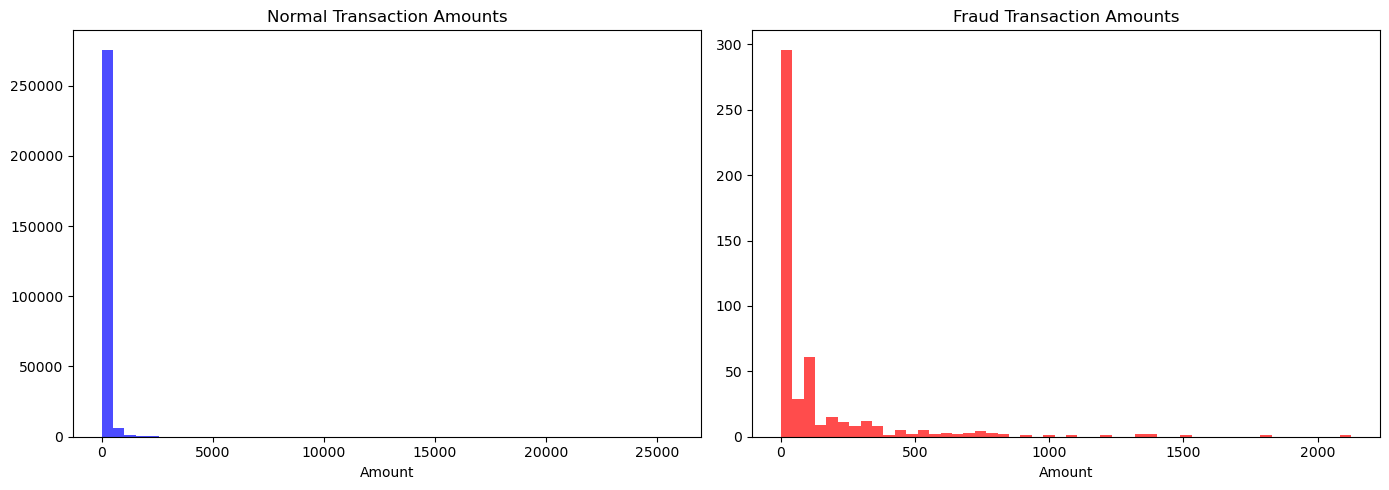

In [4]:
print("Fraud transactions - Amount stats:")
print(df[df['Class']==1]['Amount'].describe())

print("\nNormal transactions - Amount stats:")
print(df[df['Class']==0]['Amount'].describe())

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df[df['Class']==0]['Amount'], bins=50, color='blue', alpha=0.7)
axes[0].set_title('Normal Transaction Amounts')
axes[0].set_xlabel('Amount')

axes[1].hist(df[df['Class']==1]['Amount'], bins=50, color='red', alpha=0.7)
axes[1].set_title('Fraud Transaction Amounts')
axes[1].set_xlabel('Amount')

plt.tight_layout()
plt.show()

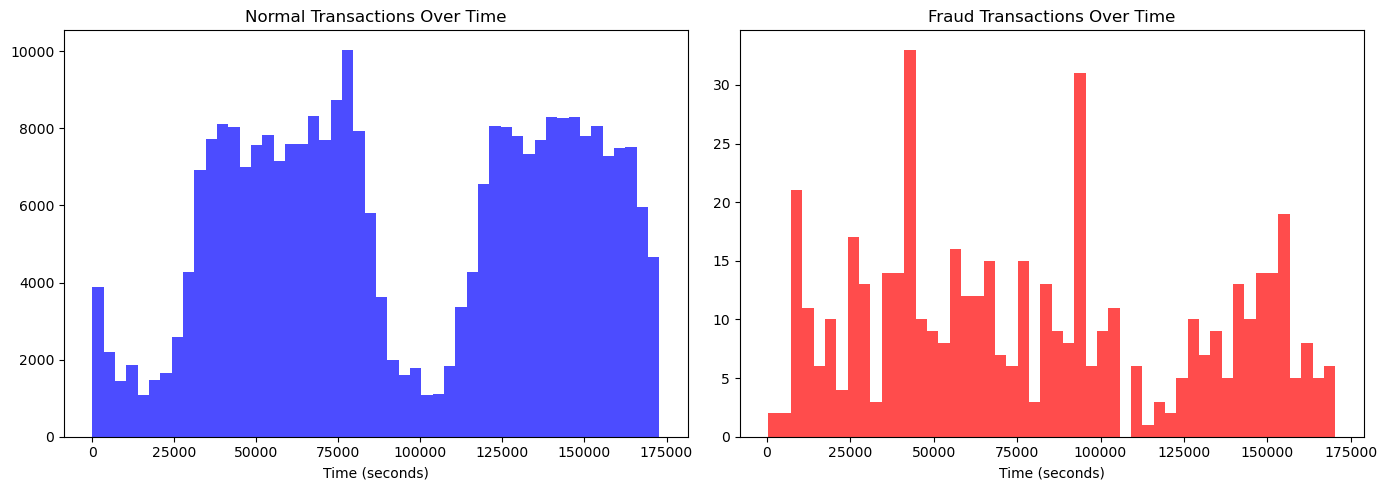

In [5]:
# Time analysis
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df[df['Class']==0]['Time'], bins=50, color='blue', alpha=0.7)
axes[0].set_title('Normal Transactions Over Time')
axes[0].set_xlabel('Time (seconds)')

axes[1].hist(df[df['Class']==1]['Time'], bins=50, color='red', alpha=0.7)
axes[1].set_title('Fraud Transactions Over Time')
axes[1].set_xlabel('Time (seconds)')

plt.tight_layout()
plt.show()

Top features positively correlated with fraud:
Class    1.000000
V11      0.154876
V4       0.133447
V2       0.091289
V21      0.040413
V19      0.034783
V20      0.020090
V8       0.019875
V27      0.017580
V28      0.009536
Name: Class, dtype: float64

Top features negatively correlated with fraud:
V9    -0.097733
V1    -0.101347
V18   -0.111485
V7    -0.187257
V3    -0.192961
V16   -0.196539
V10   -0.216883
V12   -0.260593
V14   -0.302544
V17   -0.326481
Name: Class, dtype: float64


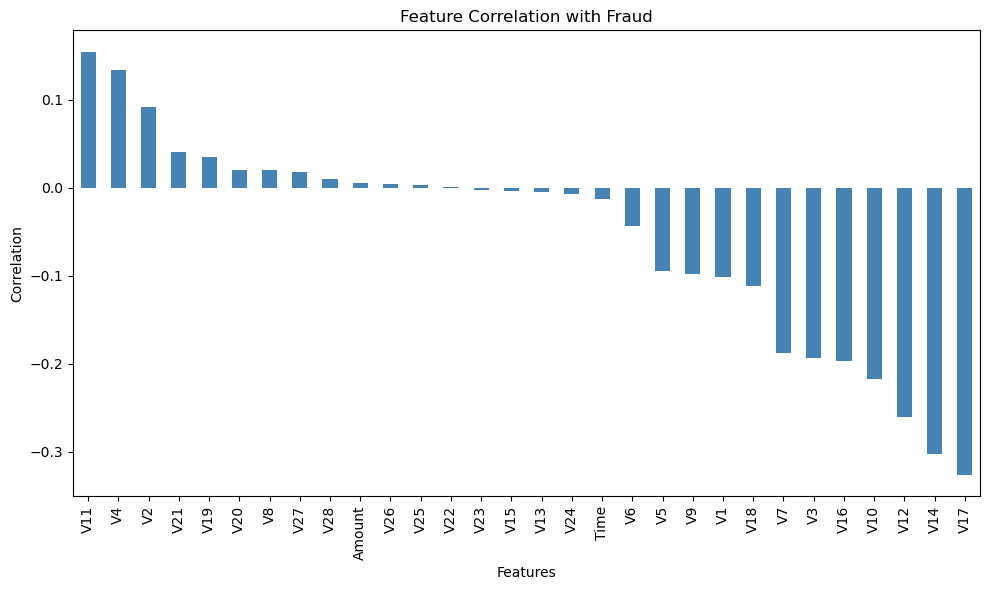

In [6]:
# Correlation with fraud
correlation = df.corr()['Class'].sort_values(ascending=False)
print("Top features positively correlated with fraud:")
print(correlation.head(10))
print("\nTop features negatively correlated with fraud:")
print(correlation.tail(10))

# Visualize
plt.figure(figsize=(10, 6))
correlation.drop('Class').plot(kind='bar', color='steelblue')
plt.title('Feature Correlation with Fraud')
plt.xlabel('Features')
plt.ylabel('Correlation')
plt.tight_layout()
plt.show()

In [7]:
from sklearn.preprocessing import StandardScaler


scaler = StandardScaler()
df['Amount_Scaled'] = scaler.fit_transform(df[['Amount']])
df['Time_Scaled'] = scaler.fit_transform(df[['Time']])

# Drop original Amount and Time
df_model = df.drop(['Time', 'Amount'], axis=1)

# Split features and target
X = df_model.drop('Class', axis=1)
y = df_model['Class']

print("Features shape:", X.shape)
print("Target distribution:\n", y.value_counts())

Features shape: (284807, 30)
Target distribution:
 Class
0    284315
1       492
Name: count, dtype: int64


In [8]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split

# Split first
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# Apply SMOTE only on training data
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", X_train.shape, y_train.value_counts().to_dict())
print("After SMOTE:", X_train_smote.shape, y_train_smote.value_counts().to_dict())

Before SMOTE: (227845, 30) {0: 227451, 1: 394}
After SMOTE: (454902, 30) {0: 227451, 1: 227451}


Training model...

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.81      0.81      0.81        98

    accuracy                           1.00     56962
   macro avg       0.91      0.90      0.90     56962
weighted avg       1.00      1.00      1.00     56962



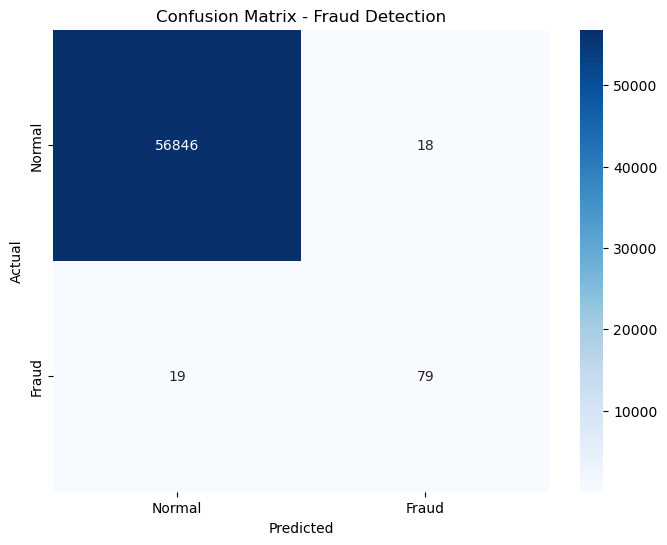

In [9]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Train model
print("Training model...")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train_smote, y_train_smote)

# Predict
y_pred = rf_model.predict(X_test)

# Results
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Fraud'],
            yticklabels=['Normal', 'Fraud'])
plt.title('Confusion Matrix - Fraud Detection')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

C:\Users\kkris\AppData\Local\Temp\ipykernel_25328\491119850.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance, palette='viridis')


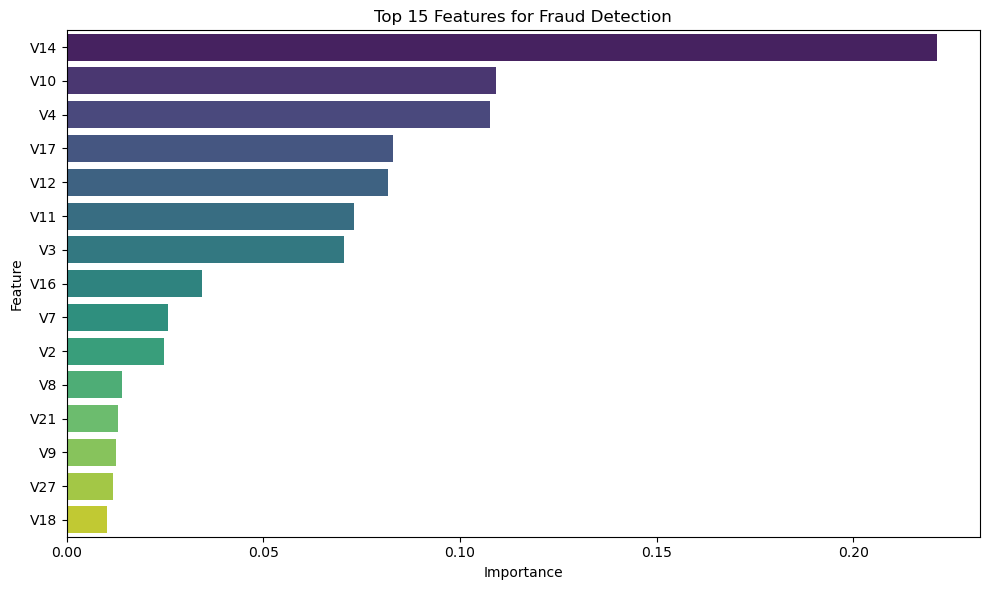

   Feature  Importance
13     V14    0.221167
9      V10    0.109198
3       V4    0.107600
16     V17    0.083030
11     V12    0.081767
10     V11    0.073116
2       V3    0.070656
15     V16    0.034398
6       V7    0.025792
1       V2    0.024697
7       V8    0.013977
20     V21    0.013102
8       V9    0.012461
26     V27    0.011689
17     V18    0.010391


In [10]:
# Feature importance
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance, palette='viridis')
plt.title('Top 15 Features for Fraud Detection')
plt.tight_layout()
plt.show()

print(importance)

In [11]:
# xgboost comparing
!pip install xgboost
from xgboost import XGBClassifier

print("Training XGBoost...")
xgb_model = XGBClassifier(random_state=42, eval_metric='logloss')
xgb_model.fit(X_train_smote, y_train_smote)

y_pred_xgb = xgb_model.predict(X_test)

print("\nXGBoost Classification Report:")
print(classification_report(y_test, y_pred_xgb))

Training XGBoost...

XGBoost Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.73      0.89      0.80        98

    accuracy                           1.00     56962
   macro avg       0.87      0.94      0.90     56962
weighted avg       1.00      1.00      1.00     56962



In [12]:
# Export data for Power BI dashboard
# Add prediction columns
X_test_copy = X_test.copy()
X_test_copy['Actual'] = y_test.values
X_test_copy['RF_Predicted'] = y_pred
X_test_copy['XGB_Predicted'] = y_pred_xgb
X_test_copy['Amount'] = df.loc[y_test.index, 'Amount'].values
X_test_copy['Time'] = df.loc[y_test.index, 'Time'].values

# Convert time to hours
X_test_copy['Hour'] = (X_test_copy['Time'] // 3600) % 24

# Add amount buckets
X_test_copy['Amount_Bucket'] = pd.cut(
    X_test_copy['Amount'],
    bins=[0, 10, 50, 100, 500, 1000, 50000],
    labels=['0-10', '10-50', '50-100', '100-500', '500-1000', '1000+']
)

# Export
X_test_copy.to_csv('fraud_dashboard_data.csv', index=False)
print("Exported successfully!")
print("Shape:", X_test_copy.shape)
print("Columns:", X_test_copy.columns.tolist())

Exported successfully!
Shape: (56962, 37)
Columns: ['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount_Scaled', 'Time_Scaled', 'Actual', 'RF_Predicted', 'XGB_Predicted', 'Amount', 'Time', 'Hour', 'Amount_Bucket']


In [13]:
X_test_copy.to_csv(r'C:\Users\kkris\Desktop\fraud_dashboard_data.csv', index=False)
print("Saved to Desktop!")

Saved to Desktop!


In [ ]:
X_test_copy.to_csv(r'C:\Users\kkris\Desktop\fraud_dashboard_data.csv', index=False)
print("Saved!")